# 02 — Training and Evaluation

This notebook trains and evaluates squat-posture classifiers using the dataset explored in Notebook 01.

The notebook includes:
1. Download and locate the dataset
2. Configuration
3. Prepare features
4. Leakage-safe group splitting
5. Preprocessing
6. Models: Logistic Regression, Random Forrest and HistGradientBoosting
7. Cross-validation
8. Learning Curve
9. Statitical testing
10. Save the best model
11. Additional tests: Leave-One-Video-Out validation and per-vide performance

In [1]:
from pathlib import Path
import json
import warnings

import kagglehub
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import (
    GroupShuffleSplit,
    GroupKFold,
    cross_validate,
    learning_curve,
)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.inspection import permutation_importance
from sklearn.dummy import DummyClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TEST_SIZE = 0.20

PROJECT_DIR = Path.cwd()
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)

Project directory: C:\Users\boale\Deep Neural Engineering


## 1. Download and locate the dataset

In [2]:
DATASET_HANDLE = "thashmiladewmini/squat-exercise-pose-dataset"

dataset_path = Path(
    kagglehub.dataset_download(DATASET_HANDLE)
)

print("Dataset path:", dataset_path)

csv_files = sorted(dataset_path.rglob("*.csv"))

if not csv_files:
    raise FileNotFoundError(
        f"No CSV files found in {dataset_path}"
    )

for index, csv_path in enumerate(csv_files):
    preview = pd.read_csv(csv_path, nrows=3)
    print(
        f"[{index}] {csv_path.name}: "
        f"{len(preview.columns)} columns"
    )
    print(list(preview.columns))

Dataset path: C:\Users\boale\.cache\kagglehub\datasets\thashmiladewmini\squat-exercise-pose-dataset\versions\1
[0] squat_features_augmented.csv: 15 columns
['left_knee_angle', 'right_knee_angle', 'left_hip_angle', 'right_hip_angle', 'left_ankle_angle', 'right_ankle_angle', 'spine_angle', 'torso_lean', 'left_knee_lateral', 'right_knee_lateral', 'symmetry_score', 'hip_depth', 'video_file', 'frame', 'label']


## 2. Configuration

In [3]:
CSV_INDEX = 0

TARGET_COLUMN = "label"
GROUP_COLUMN = "video_file"
DROP_COLUMNS = ["frame"]

csv_path = csv_files[CSV_INDEX]
df = pd.read_csv(csv_path)

print("Loaded:", csv_path.name)
print("Shape:", df.shape)
display(df.head())

Loaded: squat_features_augmented.csv
Shape: (47442, 15)


,left_knee_angle,right_knee_angle,left_hip_angle,right_hip_angle,left_ankle_angle,right_ankle_angle,spine_angle,torso_lean,left_knee_lateral,right_knee_lateral,symmetry_score,hip_depth,video_file,frame,label
0,120.254411,102.110289,149.682786,141.059426,77.30243,70.434401,149.682786,95.286652,0.077956,0.090834,26.767481,0.444815,co1.mp4,0,0
1,132.223949,116.930256,164.205496,146.066398,77.30243,70.434401,149.682786,95.286652,0.077956,0.090834,26.767481,0.444815,co1.mp4,0,1
2,120.254411,102.110289,149.682786,141.059426,77.30243,70.434401,139.120795,108.975838,0.077956,0.090834,26.767481,0.444815,co1.mp4,0,2
3,102.034287,83.887751,149.682786,141.059426,77.30243,70.434401,149.682786,95.286652,0.121875,0.140702,26.767481,0.444815,co1.mp4,0,3
4,120.254411,102.110289,149.682786,141.059426,101.23405,84.996304,149.682786,95.286652,0.077956,0.090834,26.767481,0.444815,co1.mp4,0,4


In [4]:
required_columns = {
    TARGET_COLUMN,
    GROUP_COLUMN,
    *DROP_COLUMNS,
}

missing_required = required_columns.difference(df.columns)

if missing_required:
    raise KeyError(
        f"Missing required columns: {sorted(missing_required)}"
    )

df = df.dropna(subset=[TARGET_COLUMN, GROUP_COLUMN]).copy()

print("Class counts:")
display(df[TARGET_COLUMN].value_counts().to_frame("count"))

print("Group counts:")
display(df[GROUP_COLUMN].value_counts().to_frame("rows"))

Class counts:


,count
label,
0,7907
1,7907
2,7907
3,7907
4,7907
5,7907


Group counts:


,rows
video_file,
co14.mp4,6246
co12.mp4,4704
co5.mp4,3594
co13.mp4,3480
co9.mp4,3180
co10.mp4,3036
co2.mp4,3036
co8.mp4,3036
co1.mp4,2736


## 3. Prepare features

In [5]:
columns_to_remove = [
    TARGET_COLUMN,
    GROUP_COLUMN,
    *DROP_COLUMNS,
]

X = df.drop(columns=columns_to_remove, errors="ignore")
y = df[TARGET_COLUMN].astype(str)
groups = df[GROUP_COLUMN].astype(str)

constant_columns = [
    column
    for column in X.columns
    if X[column].nunique(dropna=True) <= 1
]

X = X.drop(columns=constant_columns, errors="ignore")

print("Feature matrix shape:", X.shape)
print("Removed constant columns:", constant_columns)
print("Features:")
print(list(X.columns))

Feature matrix shape: (47442, 12)
Removed constant columns: []
Features:
['left_knee_angle', 'right_knee_angle', 'left_hip_angle', 'right_hip_angle', 'left_ankle_angle', 'right_ankle_angle', 'spine_angle', 'torso_lean', 'left_knee_lateral', 'right_knee_lateral', 'symmetry_score', 'hip_depth']


## 4. Leakage-safe train/test split

In [6]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_indices, test_indices = next(
    splitter.split(X, y, groups)
)

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

groups_train = groups.iloc[train_indices].copy()
groups_test = groups.iloc[test_indices].copy()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Training videos:", sorted(groups_train.unique()))
print("Testing videos:", sorted(groups_test.unique()))

overlap = set(groups_train).intersection(set(groups_test))
print("Group overlap:", overlap)

assert not overlap, "Data leakage detected: groups overlap."

Train shape: (40266, 12)
Test shape: (7176, 12)
Training videos: ['co10.mp4', 'co11.mp4', 'co12.mp4', 'co13.mp4', 'co14.mp4', 'co15.mp4', 'co2.mp4', 'co3.mp4', 'co5.mp4', 'co7.mp4', 'co8.mp4', 'co9.mp4']
Testing videos: ['co1.mp4', 'co4.mp4', 'co6.mp4']
Group overlap: set()


In [7]:
print("Training class distribution:")
display(y_train.value_counts(normalize=True).sort_index().to_frame("proportion"))

print("Testing class distribution:")
display(y_test.value_counts(normalize=True).sort_index().to_frame("proportion"))

Training class distribution:


,proportion
label,
0,0.166667
1,0.166667
2,0.166667
3,0.166667
4,0.166667
5,0.166667


Testing class distribution:


,proportion
label,
0,0.166667
1,0.166667
2,0.166667
3,0.166667
4,0.166667
5,0.166667


## 5. Preprocessing

In [8]:
numeric_columns = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_columns = X_train.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_columns),
        ("categorical", categorical_pipeline, categorical_columns),
    ],
    remainder="drop",
)

print("Numeric features:", len(numeric_columns))
print("Categorical features:", len(categorical_columns))

Numeric features: 12
Categorical features: 0


## 6. Models

The notebook compares three models:

- Logistic Regression: interpretable linear baseline
- Random Forest: nonlinear ensemble with class weighting
- HistGradientBoosting: strong tabular-data model

In [9]:
models = {
    "logistic_regression": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        C=1.0,
        random_state=RANDOM_STATE,
    ),

    "random_forest": RandomForestClassifier(
        n_estimators=700,
        max_depth=20,
        min_samples_split=4,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),

    "hist_gradient_boosting": HistGradientBoostingClassifier(
        learning_rate=0.08,
        max_iter=300,
        max_leaf_nodes=31,
        min_samples_leaf=20,
        l2_regularization=0.1,
        random_state=RANDOM_STATE,
    ),
}

## Train and compare models

In [10]:
results = []
fitted_models = {}
predictions = {}

for model_name, estimator in models.items():
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", estimator),
    ])

    print(f"Training {model_name}...")
    pipeline.fit(X_train, y_train)

    predicted = pipeline.predict(X_test)

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, predicted),
        "balanced_accuracy": balanced_accuracy_score(
            y_test,
            predicted,
        ),
        "macro_f1": f1_score(
            y_test,
            predicted,
            average="macro",
        ),
        "weighted_f1": f1_score(
            y_test,
            predicted,
            average="weighted",
        ),
    }

    results.append(metrics)
    fitted_models[model_name] = pipeline
    predictions[model_name] = predicted

results_df = (
    pd.DataFrame(results)
    .sort_values(
        ["macro_f1", "balanced_accuracy"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(results_df.style.format({
    "accuracy": "{:.4f}",
    "balanced_accuracy": "{:.4f}",
    "macro_f1": "{:.4f}",
    "weighted_f1": "{:.4f}",
}))

Training logistic_regression...
Training random_forest...
Training hist_gradient_boosting...


,model,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,hist_gradient_boosting,0.6060,0.6060,0.6138,0.6138
1,logistic_regression,0.4972,0.4972,0.5086,0.5086
2,random_forest,0.5020,0.5020,0.4813,0.4813


**Model Comparisation:**
Among the evaluated models, HistGradientBoosting achieved the highest overall performance, obtaining an accuracy of 60.6% and a macro F1-score of 0.614. The Logistic Regression and Random Forest models achieved lower performance with accuracies close to 50%.

These results indicate that the relationship between the pose features and thetarget posture classes is non-linear. Consequently, the gradient  boosting model was better able to capture the underlying patterns in the dataset than the linear or bagging-based approaches.

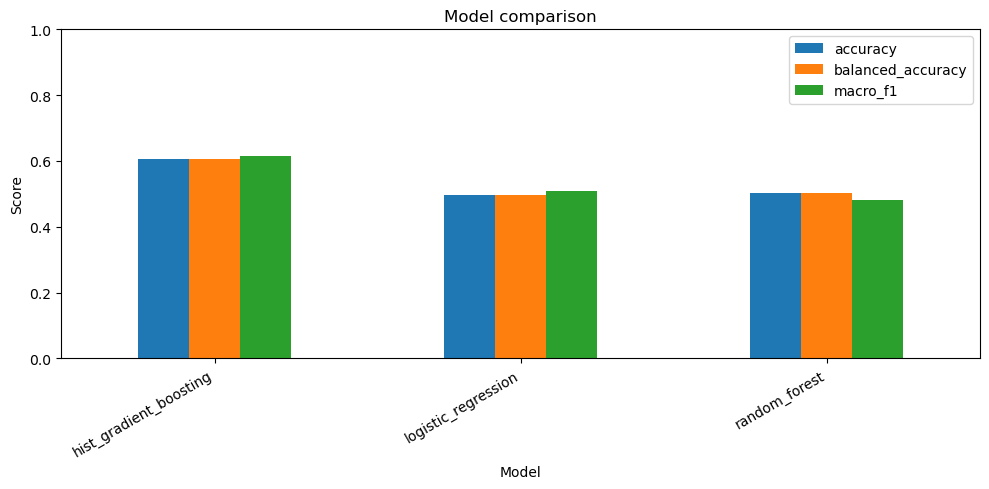

Saved: C:\Users\boale\Deep Neural Engineering\outputs\figures\model_comparison.png


In [11]:
ax = results_df.set_index("model")[
    ["accuracy", "balanced_accuracy", "macro_f1"]
].plot(
    kind="bar",
    figsize=(10, 5),
    title="Model comparison",
)

ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_xlabel("Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

comparison_path = FIGURE_DIR / "model_comparison.png"
plt.savefig(comparison_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", comparison_path)

**Interpretation:** The comparison plot shows that HistGradientBoosting consistently achieved the highest scores across all evaluation metrics, including accuracy, balanced accuracy, and macro F1-score.

The relatively small difference between accuracy and balanced accuracy suggests that the model performs reasonably consistently across the different posture classes rather than relying heavily on a few dominant classes.

## Best-model evaluation

In [12]:
best_model_name = results_df.iloc[0]["model"]
best_model = fitted_models[best_model_name]
best_predictions = predictions[best_model_name]

print("Best model:", best_model_name)
print()
print(
    classification_report(
        y_test,
        best_predictions,
        digits=4,
        zero_division=0,
    )
)

Best model: hist_gradient_boosting

              precision    recall  f1-score   support

           0     0.7405    0.5033    0.5993      1196
           1     0.8224    0.5226    0.6391      1196
           2     0.7280    0.6781    0.7022      1196
           3     0.3904    0.6313    0.4824      1196
           4     0.7219    0.7575    0.7393      1196
           5     0.5000    0.5435    0.5208      1196

    accuracy                         0.6060      7176
   macro avg     0.6505    0.6060    0.6138      7176
weighted avg     0.6505    0.6060    0.6138      7176



In [13]:
report_dict = classification_report(
    y_test,
    best_predictions,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report_dict).T
display(report_df)

report_path = OUTPUT_DIR / "classification_report.csv"
report_df.to_csv(report_path)

print("Saved:", report_path)

,precision,recall,f1-score,support
0,0.740467,0.503344,0.599303,1196.000000
1,0.822368,0.522575,0.639059,1196.000000
2,0.728007,0.678094,0.702165,1196.000000
3,0.390383,0.631271,0.482428,1196.000000
4,0.721912,0.757525,0.739290,1196.000000
5,0.500000,0.543478,0.520833,1196.000000
accuracy,0.606048,0.606048,0.606048,0.606048
macro avg,0.650523,0.606048,0.613846,7176.000000
weighted avg,0.650523,0.606048,0.613846,7176.000000


Saved: C:\Users\boale\Deep Neural Engineering\outputs\classification_report.csv


## Raw confusion matrix

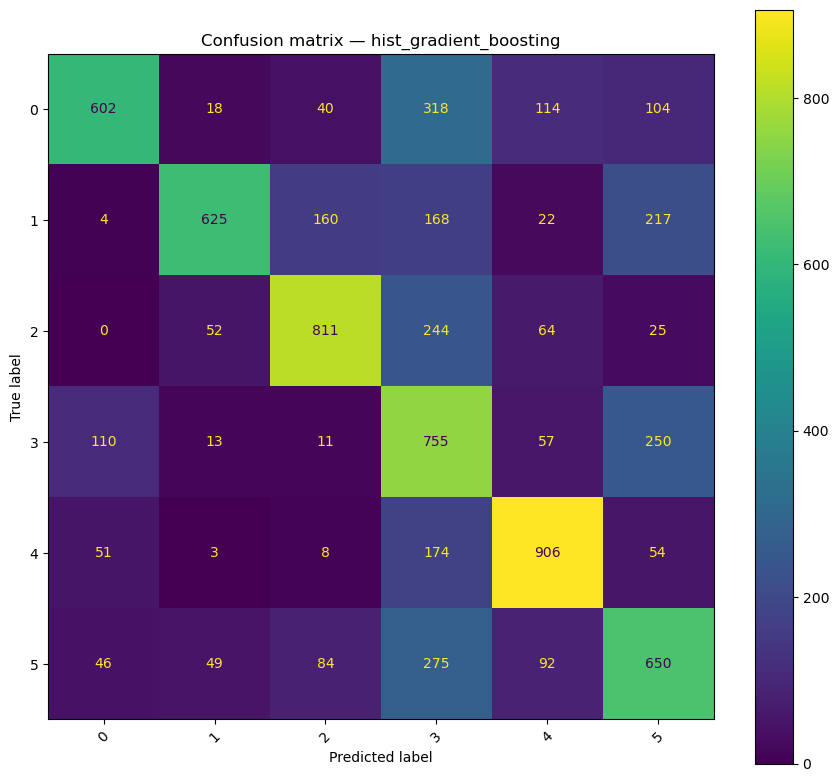

Saved: C:\Users\boale\Deep Neural Engineering\outputs\figures\confusion_matrix_raw.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    xticks_rotation=45,
    ax=ax,
)

ax.set_title(
    f"Confusion matrix — {best_model_name}"
)

plt.tight_layout()

raw_cm_path = FIGURE_DIR / "confusion_matrix_raw.png"
plt.savefig(raw_cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", raw_cm_path)

## Normalized confusion matrix

Each row sums to approximately 1. This makes class-level recall easier to compare.

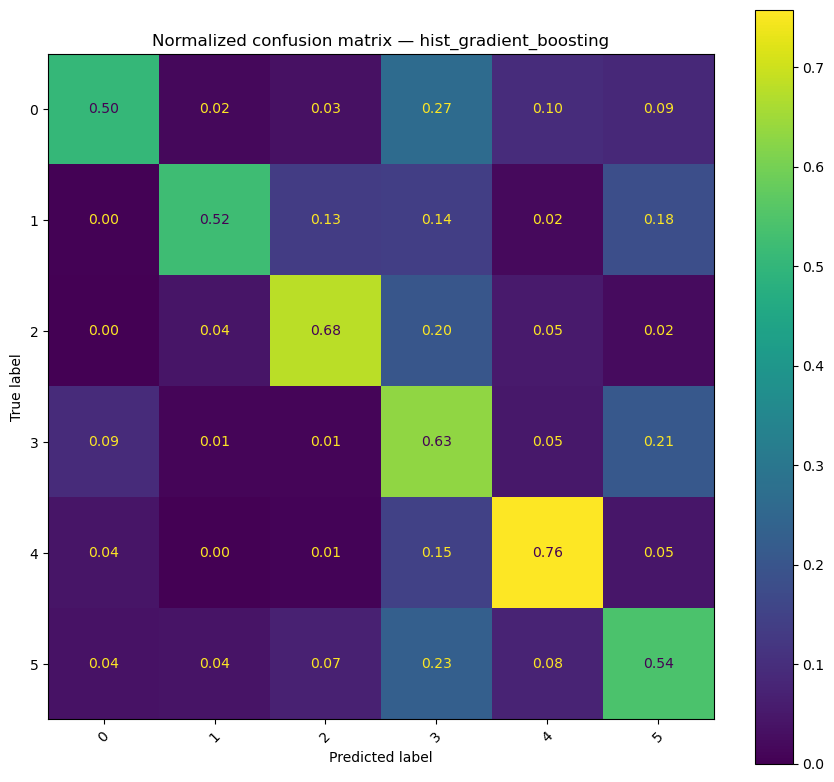

Saved: C:\Users\boale\Deep Neural Engineering\outputs\figures\confusion_matrix_normalized.png


In [15]:
fig, ax = plt.subplots(figsize=(9, 8))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_predictions,
    normalize="true",
    values_format=".2f",
    xticks_rotation=45,
    ax=ax,
)

ax.set_title(
    f"Normalized confusion matrix — {best_model_name}"
)

plt.tight_layout()

normalized_cm_path = (
    FIGURE_DIR / "confusion_matrix_normalized.png"
)

plt.savefig(
    normalized_cm_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", normalized_cm_path)

## Random Forest feature importance

This section runs whenever the Random Forest model has been trained, even if it is not the best model.

,feature,importance
1,numeric__right_knee_angle,0.135507
0,numeric__left_knee_angle,0.119239
7,numeric__torso_lean,0.099804
4,numeric__left_ankle_angle,0.095019
5,numeric__right_ankle_angle,0.091950
6,numeric__spine_angle,0.085670
9,numeric__right_knee_lateral,0.074545
8,numeric__left_knee_lateral,0.074352
2,numeric__left_hip_angle,0.068722
11,numeric__hip_depth,0.068372


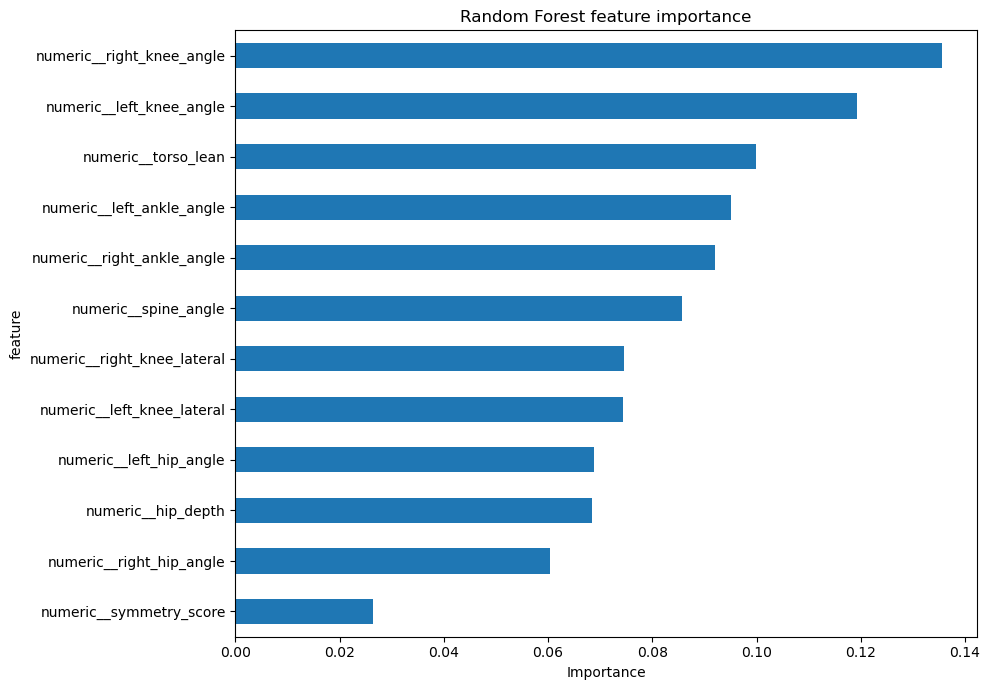

Saved: C:\Users\boale\Deep Neural Engineering\outputs\figures\random_forest_feature_importance.png


In [16]:
rf_pipeline = fitted_models["random_forest"]

transformed_feature_names = (
    rf_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

rf_importances = (
    rf_pipeline
    .named_steps["classifier"]
    .feature_importances_
)

rf_importance_df = (
    pd.DataFrame({
        "feature": transformed_feature_names,
        "importance": rf_importances,
    })
    .sort_values("importance", ascending=False)
    .head(20)
)

display(rf_importance_df)

ax = (
    rf_importance_df
    .sort_values("importance")
    .plot(
        kind="barh",
        x="feature",
        y="importance",
        legend=False,
        figsize=(10, 7),
        title="Random Forest feature importance",
    )
)

ax.set_xlabel("Importance")
plt.tight_layout()

rf_importance_path = (
    FIGURE_DIR / "random_forest_feature_importance.png"
)

plt.savefig(
    rf_importance_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

rf_importance_df.to_csv(
    OUTPUT_DIR / "random_forest_feature_importance.csv",
    index=False,
)

print("Saved:", rf_importance_path)

## Permutation importance for the best model

Permutation importance measures how much performance decreases when one original input feature is shuffled.

,feature,importance_mean,importance_std
6,spine_angle,0.249377,0.002809
2,left_hip_angle,0.195342,0.004018
1,right_knee_angle,0.174517,0.003871
0,left_knee_angle,0.171789,0.004126
3,right_hip_angle,0.123615,0.003253
5,right_ankle_angle,0.087630,0.005846
9,right_knee_lateral,0.066776,0.004447
11,hip_depth,0.058678,0.003727
7,torso_lean,0.048825,0.000905
8,left_knee_lateral,0.042729,0.003113


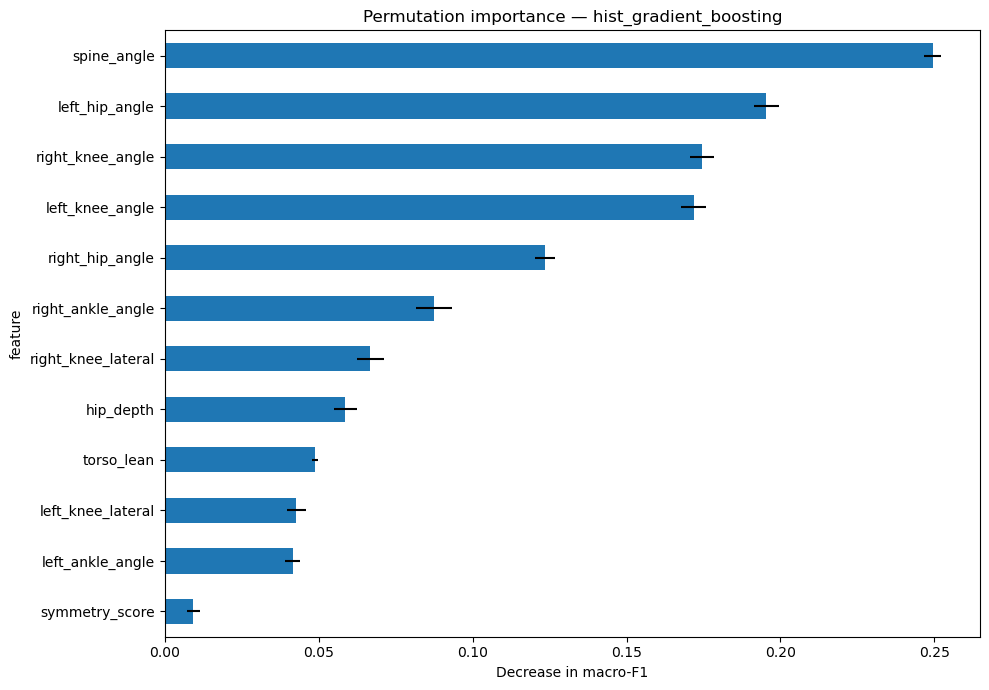

Saved: C:\Users\boale\Deep Neural Engineering\outputs\figures\permutation_importance.png


In [17]:
permutation = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

permutation_df = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": permutation.importances_mean,
        "importance_std": permutation.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .head(20)
)

display(permutation_df)

ax = (
    permutation_df
    .sort_values("importance_mean")
    .plot(
        kind="barh",
        x="feature",
        y="importance_mean",
        xerr="importance_std",
        legend=False,
        figsize=(10, 7),
        title=f"Permutation importance — {best_model_name}",
    )
)

ax.set_xlabel("Decrease in macro-F1")
plt.tight_layout()

permutation_path = (
    FIGURE_DIR / "permutation_importance.png"
)

plt.savefig(
    permutation_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

permutation_df.to_csv(
    OUTPUT_DIR / "permutation_importance.csv",
    index=False,
)

print("Saved:", permutation_path)

## 7. Cross-validation

In [18]:
RUN_GROUPED_CV = True

if RUN_GROUPED_CV:
    number_of_groups = groups.nunique()
    n_splits = min(5, number_of_groups)

    group_cv = GroupKFold(n_splits=n_splits)

    scoring = {
        "accuracy": "accuracy",
        "balanced_accuracy": "balanced_accuracy",
        "macro_f1": "f1_macro",
        "weighted_f1": "f1_weighted",
    }

    cv_results = cross_validate(
        best_model,
        X,
        y,
        groups=groups,
        cv=group_cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    cv_summary = []

    for metric_name in scoring:
        values = cv_results[f"test_{metric_name}"]

        cv_summary.append({
            "metric": metric_name,
            "mean": values.mean(),
            "std": values.std(),
            "minimum": values.min(),
            "maximum": values.max(),
        })

    cv_summary_df = pd.DataFrame(cv_summary)

    display(cv_summary_df.style.format({
        "mean": "{:.4f}",
        "std": "{:.4f}",
        "minimum": "{:.4f}",
        "maximum": "{:.4f}",
    }))

    cv_summary_df.to_csv(
        OUTPUT_DIR / "grouped_cross_validation_summary.csv",
        index=False,
    )
else:
    print("Grouped cross-validation skipped.")

,metric,mean,std,minimum,maximum
0,accuracy,0.5665,0.1600,0.2579,0.7250
1,balanced_accuracy,0.5665,0.1600,0.2579,0.7250
2,macro_f1,0.5514,0.2000,0.1617,0.7346
3,weighted_f1,0.5514,0.2000,0.1617,0.7346


**Results:** The average cross-validation scores are slightly lower than the single hold-out test results. This is expected because grouped validation prevents frames from the same video appearing in both the training and testing sets, providing a more realistic estimate of model performance.

The variation between folds indicates that model performance depends on thecharacteristics of individual videos, such as camera angle, movement style and subject variability.

## 8. Learning curve

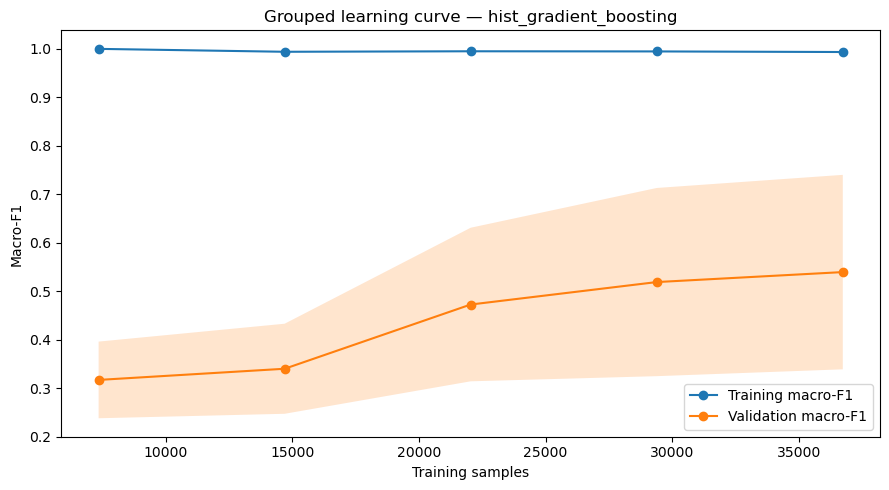

Saved: C:\Users\boale\Deep Neural Engineering\outputs\figures\learning_curve.png


In [19]:
RUN_LEARNING_CURVE = True

if RUN_LEARNING_CURVE:
    group_cv = GroupKFold(
        n_splits=min(5, groups.nunique())
    )

    train_sizes, train_scores, validation_scores = learning_curve(
        estimator=best_model,
        X=X,
        y=y,
        groups=groups,
        cv=group_cv,
        scoring="f1_macro",
        train_sizes=np.linspace(0.2, 1.0, 5),
        n_jobs=-1,
        shuffle=False,
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    validation_mean = validation_scores.mean(axis=1)
    validation_std = validation_scores.std(axis=1)

    fig, ax = plt.subplots(figsize=(9, 5))

    ax.plot(
        train_sizes,
        train_mean,
        marker="o",
        label="Training macro-F1",
    )

    ax.plot(
        train_sizes,
        validation_mean,
        marker="o",
        label="Validation macro-F1",
    )

    ax.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2,
    )

    ax.fill_between(
        train_sizes,
        validation_mean - validation_std,
        validation_mean + validation_std,
        alpha=0.2,
    )

    ax.set_xlabel("Training samples")
    ax.set_ylabel("Macro-F1")
    ax.set_title(
        f"Grouped learning curve — {best_model_name}"
    )
    ax.legend()

    plt.tight_layout()

    learning_curve_path = (
        FIGURE_DIR / "learning_curve.png"
    )

    plt.savefig(
        learning_curve_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved:", learning_curve_path)
else:
    print("Learning curve skipped.")

**Interpretation:** The curve suggests that the model benefits from larger training sets and has not fully reached a performance plateau. Therefore, collecting additional labelled videos would likely improve the classifier's ability to generalise to new subjects and recording conditions.

## 9. Statistical tests

In [25]:
from itertools import combinations

import numpy as np
import pandas as pd

from scipy.stats import friedmanchisquare, wilcoxon
from sklearn.base import clone
from sklearn.metrics import f1_score
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.pipeline import Pipeline


ALPHA = 0.05
logo = LeaveOneGroupOut()
rows = []

# Evaluate every model on the same held-out videos.
for train_idx, validation_idx in logo.split(
    X_train,
    y_train,
    groups=groups_train,
):
    held_out_video = groups_train.iloc[validation_idx].unique()[0]

    for model_name, estimator in models.items():
        pipeline = Pipeline([
            ("preprocessor", clone(preprocessor)),
            ("classifier", clone(estimator)),
        ])

        pipeline.fit(
            X_train.iloc[train_idx],
            y_train.iloc[train_idx],
        )

        predictions = pipeline.predict(
            X_train.iloc[validation_idx]
        )

        rows.append({
            "video": held_out_video,
            "model": model_name,
            "macro_f1": f1_score(
                y_train.iloc[validation_idx],
                predictions,
                average="macro",
                zero_division=0,
            ),
        })

statistical_scores = pd.DataFrame(rows)

score_table = statistical_scores.pivot(
    index="video",
    columns="model",
    values="macro_f1",
)

display(
    statistical_scores
    .groupby("model")["macro_f1"]
    .agg(["mean", "std", "median"])
    .round(4)
)

# Overall Friedman test
model_names = list(score_table.columns)

friedman_statistic, friedman_p = friedmanchisquare(
    *[score_table[name] for name in model_names]
)

print("\nFriedman test")
print(f"Statistic: {friedman_statistic:.4f}")
print(f"p-value:   {friedman_p:.6f}")


def holm_adjust(p_values):
    """Holm correction for multiple comparisons."""
    p_values = np.asarray(p_values, dtype=float)
    order = np.argsort(p_values)
    adjusted = np.empty(len(p_values))
    previous = 0.0

    for rank, index in enumerate(order):
        corrected = (len(p_values) - rank) * p_values[index]
        previous = max(previous, corrected)
        adjusted[index] = min(previous, 1.0)

    return adjusted


# Pairwise tests
pairwise_rows = []

for model_a, model_b in combinations(model_names, 2):
    scores_a = score_table[model_a].to_numpy()
    scores_b = score_table[model_b].to_numpy()

    if np.allclose(scores_a, scores_b):
        statistic, p_value = 0.0, 1.0
    else:
        statistic, p_value = wilcoxon(
            scores_a,
            scores_b,
            alternative="two-sided",
        )

    pairwise_rows.append({
        "model_a": model_a,
        "model_b": model_b,
        "statistic": statistic,
        "raw_p": p_value,
        "mean_difference": np.mean(scores_a - scores_b),
    })

pairwise_results = pd.DataFrame(pairwise_rows)

pairwise_results["adjusted_p"] = holm_adjust(
    pairwise_results["raw_p"]
)

pairwise_results["significant"] = (
    pairwise_results["adjusted_p"] < ALPHA
)

display(pairwise_results.round(4))

,mean,std,median
model,,,
hist_gradient_boosting,0.5641,0.2334,0.6125
logistic_regression,0.4545,0.1153,0.4399
random_forest,0.4819,0.2073,0.5081



Friedman test
Statistic: 8.0000
p-value:   0.018316


,model_a,model_b,statistic,raw_p,mean_difference,adjusted_p,significant
0,hist_gradient_boosting,logistic_regression,16.0,0.0771,0.1095,0.1543,False
1,hist_gradient_boosting,random_forest,4.0,0.0034,0.0821,0.0103,True
2,logistic_regression,random_forest,30.0,0.5186,-0.0274,0.5186,False


## 10. Save the best model

In [26]:
model_path = (
    MODEL_DIR / "squat_posture_classifier_improved.joblib"
)

joblib.dump(best_model, model_path)

metadata = {
    "dataset_handle": DATASET_HANDLE,
    "source_csv": str(csv_path),
    "target_column": TARGET_COLUMN,
    "group_column": GROUP_COLUMN,
    "dropped_columns": DROP_COLUMNS,
    "feature_columns": X.columns.tolist(),
    "classes": sorted(y.unique().tolist()),
    "best_model": best_model_name,
    "holdout_metrics": {
        key: (
            float(value)
            if isinstance(value, (np.floating, float))
            else value
        )
        for key, value in results_df.iloc[0].to_dict().items()
    },
    "training_groups": sorted(groups_train.unique().tolist()),
    "testing_groups": sorted(groups_test.unique().tolist()),
    "random_state": RANDOM_STATE,
    "test_size": TEST_SIZE,
}

metadata_path = OUTPUT_DIR / "model_metadata.json"

metadata_path.write_text(
    json.dumps(metadata, indent=2)
)

results_df.to_csv(
    OUTPUT_DIR / "model_comparison.csv",
    index=False,
)

print("Saved model:", model_path)
print("Saved metadata:", metadata_path)
print("Saved model comparison:", OUTPUT_DIR / "model_comparison.csv")

Saved model: C:\Users\boale\Deep Neural Engineering\models\squat_posture_classifier_improved.joblib
Saved metadata: C:\Users\boale\Deep Neural Engineering\outputs\model_metadata.json
Saved model comparison: C:\Users\boale\Deep Neural Engineering\outputs\model_comparison.csv


## 11. Additional tests

## 11.1. Baseline

In [27]:
baseline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

print("=" * 60)
print("Baseline Dummy Classifier")
print("=" * 60)
print(f"Accuracy:          {accuracy_score(y_test, baseline_pred):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test, baseline_pred):.4f}")
print(f"Macro F1:          {f1_score(y_test, baseline_pred, average='macro'):.4f}")
print(f"Weighted F1:       {f1_score(y_test, baseline_pred, average='weighted'):.4f}")

Baseline Dummy Classifier
Accuracy:          0.1667
Balanced Accuracy: 0.1667
Macro F1:          0.0476
Weighted F1:       0.0476


## 11.2. Leave-One-Video-Out Validation

,fold,held_out_video,test_samples,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,12,co6.mp4,1866,0.828510,0.828510,0.822527,0.822527
1,10,co4.mp4,2574,0.817405,0.817405,0.816749,0.816749
2,15,co9.mp4,3180,0.809119,0.809119,0.807901,0.807901
3,7,co15.mp4,2592,0.792052,0.792052,0.791232,0.791232
4,11,co5.mp4,3594,0.718141,0.718141,0.736843,0.736843
5,9,co3.mp4,2580,0.730233,0.730233,0.728350,0.728350
6,2,co10.mp4,3036,0.729578,0.729578,0.722820,0.722820
7,8,co2.mp4,3036,0.659091,0.659091,0.659442,0.659442
8,13,co7.mp4,2622,0.570938,0.570938,0.582104,0.582104
9,5,co13.mp4,3480,0.529023,0.529023,0.522039,0.522039


Leave-One-Video-Out Summary
----------------------------------------


,accuracy,balanced_accuracy,macro_f1,weighted_f1
mean,0.6140,0.6140,0.6011,0.6011
std,0.1850,0.1850,0.2081,0.2081
min,0.2088,0.2088,0.1217,0.1217
max,0.8285,0.8285,0.8225,0.8225


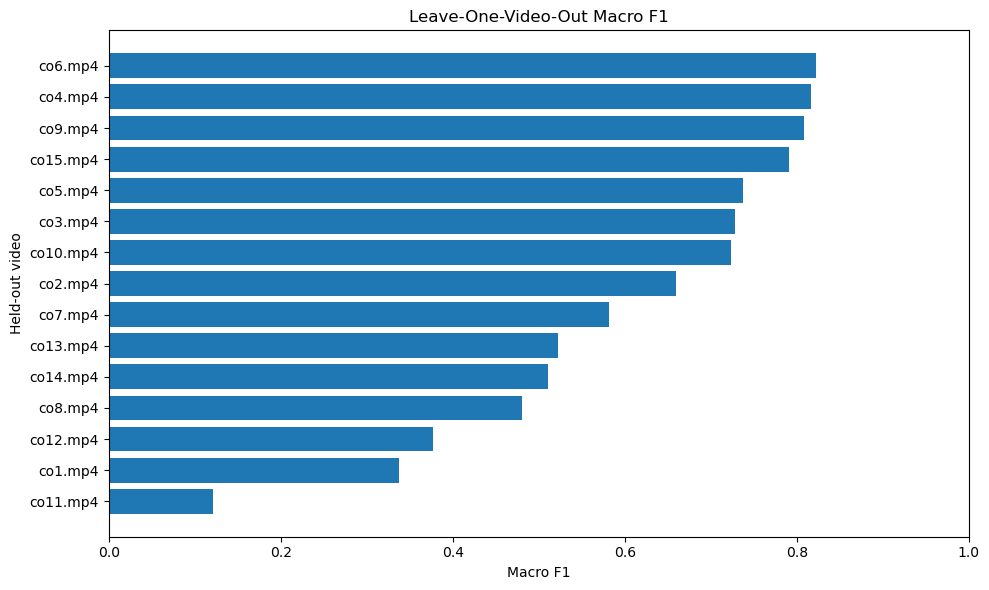

In [28]:
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.base import clone

logo = LeaveOneGroupOut()
logo_results = []

for fold_number, (train_idx, test_idx) in enumerate(
    logo.split(X, y, groups=groups),
    start=1,
):
    X_logo_train = X.iloc[train_idx]
    X_logo_test = X.iloc[test_idx]

    y_logo_train = y.iloc[train_idx]
    y_logo_test = y.iloc[test_idx]

    held_out_groups = np.asarray(groups)[test_idx]
    held_out_video = np.unique(held_out_groups)

    if len(held_out_video) != 1:
        raise ValueError(
            f"Expected one held-out video, found: {held_out_video}"
        )

    # Clone prevents the original fitted model from being overwritten
    fold_model = clone(best_model)
    fold_model.fit(X_logo_train, y_logo_train)

    fold_predictions = fold_model.predict(X_logo_test)

    logo_results.append({
        "fold": fold_number,
        "held_out_video": held_out_video[0],
        "test_samples": len(test_idx),
        "accuracy": accuracy_score(
            y_logo_test,
            fold_predictions,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_logo_test,
            fold_predictions,
        ),
        "macro_f1": f1_score(
            y_logo_test,
            fold_predictions,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            y_logo_test,
            fold_predictions,
            average="weighted",
            zero_division=0,
        ),
    })

logo_results_df = pd.DataFrame(logo_results)

display(
    logo_results_df.sort_values(
        "macro_f1",
        ascending=False,
    ).reset_index(drop=True)
)

print("Leave-One-Video-Out Summary")
print("-" * 40)

summary_columns = [
    "accuracy",
    "balanced_accuracy",
    "macro_f1",
    "weighted_f1",
]

display(
    logo_results_df[summary_columns]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)

import matplotlib.pyplot as plt

plot_data = (
    logo_results_df
    .sort_values("macro_f1", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_data["held_out_video"].astype(str),
    plot_data["macro_f1"],
)

plt.xlabel("Macro F1")
plt.ylabel("Held-out video")
plt.title("Leave-One-Video-Out Macro F1")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

## 11.3. Per-Video Performance on the Holdout Test Set

,video_file,samples,accuracy,balanced_accuracy,macro_f1,weighted_f1
0,co6.mp4,1866,0.7669,0.7669,0.7556,0.7556
1,co4.mp4,2574,0.7195,0.7195,0.7171,0.7171
2,co1.mp4,2736,0.3896,0.3896,0.3260,0.3260


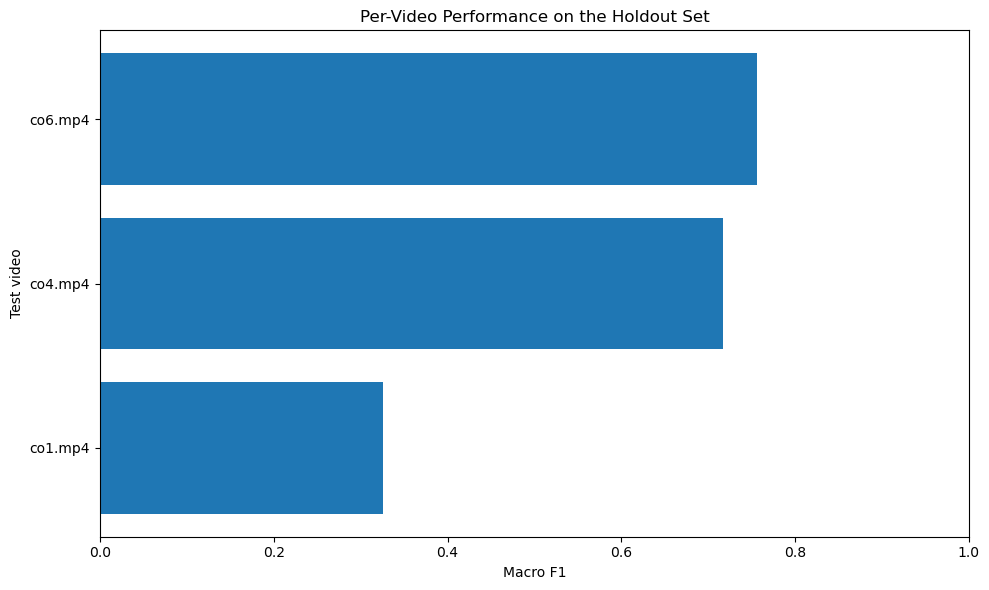

Saved: results/per_video_holdout_results.csv


In [29]:
groups_test_array = np.asarray(groups_test)
y_test_array = np.asarray(y_test)
predictions_array = np.asarray(best_predictions)

if not (
    len(groups_test_array)
    == len(y_test_array)
    == len(predictions_array)
):
    raise ValueError(
        "groups_test, y_test and best_predictions must have "
        "the same number of samples."
    )

prediction_results = pd.DataFrame({
    "video_file": groups_test_array,
    "actual": y_test_array,
    "predicted": predictions_array,
})

per_video_results = []

for video_name, video_data in prediction_results.groupby("video_file"):
    actual = video_data["actual"]
    predicted = video_data["predicted"]

    per_video_results.append({
        "video_file": video_name,
        "samples": len(video_data),
        "accuracy": accuracy_score(actual, predicted),
        "balanced_accuracy": balanced_accuracy_score(
            actual,
            predicted,
        ),
        "macro_f1": f1_score(
            actual,
            predicted,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            actual,
            predicted,
            average="weighted",
            zero_division=0,
        ),
    })

per_video_results_df = (
    pd.DataFrame(per_video_results)
    .sort_values("macro_f1", ascending=False)
    .reset_index(drop=True)
)

display(per_video_results_df.round(4))
import matplotlib.pyplot as plt
from pathlib import Path

plot_data = (
    per_video_results_df
    .sort_values("macro_f1", ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(
    plot_data["video_file"].astype(str),
    plot_data["macro_f1"],
)

plt.xlabel("Macro F1")
plt.ylabel("Test video")
plt.title("Per-Video Performance on the Holdout Set")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

results_directory = Path("results")
results_directory.mkdir(parents=True, exist_ok=True)

per_video_results_df.to_csv(
    results_directory / "per_video_holdout_results.csv",
    index=False,
)

print("Saved: results/per_video_holdout_results.csv")